<a href="https://colab.research.google.com/github/asndjkasdnjkasdjnkasdj/-Lab01_EDA_Azocar_Benjamin/blob/main/Lab01_EDA_Azocar_Benjamin_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Understading

### Determinacion de los Objetivos del negocio

Contexto del proyecto:
Este proyecto simula el contexto de una institucion educativa interesada en comprender como o que factores influyen en el rendimiento academico de sus estudiantes con el fin de diseñar estrategias de apoyo o de alerta temprana.

Objetivos del negocio: Comprender patrones de conducta en los estudiantes para saber como su estilo de vida influye en su rendimiento academico.

Criterios de exito:
-Contar de un modelo interpretable que permita identificar principales factores asociados al rendimiento academico de los estudiantes.
-Disponer d euna herramienta capaz de predecir estudiantes en riesgo de bajo rendimiento.

## Evaluacion de la situacion:

Disponibilidad de recursos: Base de datos institucional que contiene registros de asistencia, calificaciones, habitos de estudio y datos demograficos.

Requisitos del proyecto: Datos actualizados de los estudiantes, consentimiento informado de datos sensibles.

Riesgos: Ante los resultados no proceder de manera inmediata con un estudiante sino trabajar con el equipo docente a la par.

## Objetivos de la Mineria de Datos

-Constuir un modelo predictivo que pueda predecir correctamente el puntaje final de examen
-Realizar un analisis exploratorio de datos (eda) y un analisis de importancia de variables (feature importance) para identificar que factores tienen mayor influencia sobre el rendimiento academico.





Enlace Repo GitHub: https://github.com/asndjkasdnjkasdjnkasdj/-Lab01_EDA_Azocar_Benjamin/blob/main/Lab01_EDA_Azocar_Benjamin_ipynb_.ipynb

Nombre del dataset: [Student Performance & Study Habits]
Autor o publicador: [Harshada Patil]
Enlace: [https://www.kaggle.com/datasets/harshadapatil31/student-performance-and-study-habits-dataset]
Archivo seleccionado: [student_perfomance_dataset.csv]
Unidad de análisis: cada fila representa [Contains student records with study habits, lifestyle factors, demographics, and final exam performance. Used to analyze and predict academic outcomes.]
Justificación: elegí esta fuente porque [Es una fuente de datos bien diseñada para aprender mineria de datos]
Pregunta inicial: me interesa explorar [los tiempos de estudio en relacion a la cantidad de horas trabajadas]
Licencia o condiciones de uso: [CC0: Public Domain]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [ ]:
from google.colab import files
archivos_subidos = files.upload()
nombre_csv = next(iter(archivos_subidos))
print("Archivo seleccionado:", nombre_csv)


Saving student_performance_dataset.csv to student_performance_dataset.csv
Archivo seleccionado: student_performance_dataset.csv


In [ ]:
df = pd.read_csv(nombre_csv)
print("Dataset cargado correctamente")
df.head()

Dataset cargado correctamente


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.00,98.00,6.50,Bachelors,Yes,Yes,No,76.90,100.00,A
1,2,Female,6.30,100.00,5.70,High School,Yes,Yes,Yes,75.50,100.00,A
2,3,Male,4.90,85.30,7.90,Bachelors,Yes,No,Yes,88.50,97.30,A
3,4,Male,2.60,77.50,8.00,NaN,Yes,Yes,No,85.10,83.80,B
4,5,Male,2.20,89.60,4.60,Bachelors,Yes,No,Yes,61.80,68.30,D


In [ ]:
filas, columnas = df.shape
print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)


Cantidad de filas: 1000
Cantidad de columnas: 12


In [ ]:
display(df.head())
display(df.tail())
display(df.sample(n=min(5, len(df)), random_state=42))


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.00,98.00,6.50,Bachelors,Yes,Yes,No,76.90,100.00,A
1,2,Female,6.30,100.00,5.70,High School,Yes,Yes,Yes,75.50,100.00,A
2,3,Male,4.90,85.30,7.90,Bachelors,Yes,No,Yes,88.50,97.30,A
3,4,Male,2.60,77.50,8.00,NaN,Yes,Yes,No,85.10,83.80,B
4,5,Male,2.20,89.60,4.60,Bachelors,Yes,No,Yes,61.80,68.30,D


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
995,996,Male,2.80,75.40,8.20,Masters,Yes,Yes,No,60.50,70.70,C
996,997,Male,6.70,88.40,7.10,NaN,No,Yes,No,82.20,99.50,A
997,998,Female,2.60,84.50,8.00,High School,Yes,Yes,Yes,65.20,79.20,C
998,999,Female,4.60,85.30,8.10,High School,No,No,Yes,52.20,82.20,B
999,1000,Male,3.90,77.40,6.10,Masters,Yes,No,No,45.40,70.40,C


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
521,522,Male,4.60,73.70,5.40,PhD,No,Yes,Yes,74.80,71.80,C
737,738,Male,1.80,82.40,6.40,High School,Yes,No,Yes,70.90,66.60,D
740,741,Male,4.00,73.20,4.50,High School,Yes,No,No,49.40,62.90,D
660,661,Female,4.50,85.00,8.20,Bachelors,Yes,No,No,71.90,95.20,A
411,412,Female,4.50,77.00,4.70,High School,Yes,No,No,81.60,90.20,A


In [ ]:
print("Columnas disponibles:")
for numero, columna in enumerate(df.columns, start=1):
  print(numero, "−", columna)

Columnas disponibles:
1 − student_id
2 − gender
3 − study_time_hours
4 − attendance_percent
5 − sleep_hours
6 − parental_education
7 − internet_access
8 − extracurricular_activities
9 − part_time_job
10 − previous_grade
11 − final_exam_score
12 − final_grade


student_id
significado analitico: study_time_hours, sleep hours
comprensibles: study_time_hours y part_time_job
posible columna de fecha: no hay fechas
consultar en kaggle: extracurricular_activities

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [ ]:
resumen_columnas = pd.DataFrame({
"tipo_pandas": df.dtypes.astype(str),
"datos_presentes": df.notna().sum(),
"datos_nulos": df.isna().sum(),
"valores_unicos": df.nunique(dropna=True)
})
resumen_columnas


,tipo_pandas,datos_presentes,datos_nulos,valores_unicos
student_id,int64,1000,0,1000
gender,object,1000,0,2
study_time_hours,float64,1000,0,70
attendance_percent,float64,1000,0,327
sleep_hours,float64,1000,0,65
parental_education,object,898,102,4
internet_access,object,1000,0,2
extracurricular_activities,object,1000,0,2
part_time_job,object,1000,0,2
previous_grade,float64,1000,0,434


In [ ]:
columnas_numericas = df.select_dtypes(
include=np.number
).columns.tolist()
columnas_categoricas = df.select_dtypes(
include=["object", "category", "bool"]
).columns.tolist()
print("Columnas numericas:", columnas_numericas)
print("Columnas categoricas:", columnas_categoricas)

Columnas numericas: ['student_id', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']
Columnas categoricas: ['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'final_grade']


In [ ]:
if 'student_id' in columnas_numericas:
    columnas_numericas.remove('student_id')
print("Columnas numericas (sin student_id):", columnas_numericas)

Columnas numericas (sin student_id): ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']


In [ ]:
resumen_nulos = pd.DataFrame({
"cantidad_nulos": df.isnull().sum(),
"porcentaje_nulos": (df.isnull().mean() *
100).round(2)
})
resumen_nulos = resumen_nulos.sort_values(
by="porcentaje_nulos",
ascending=False
)
resumen_nulos


,cantidad_nulos,porcentaje_nulos
parental_education,102,10.20
student_id,0,0.00
study_time_hours,0,0.00
gender,0,0.00
attendance_percent,0,0.00
sleep_hours,0,0.00
internet_access,0,0.00
extracurricular_activities,0,0.00
part_time_job,0,0.00
previous_grade,0,0.00


In [ ]:
columnas_con_nulos = resumen_nulos[
resumen_nulos["cantidad_nulos"] > 0
]
columnas_con_nulos


,cantidad_nulos,porcentaje_nulos
parental_education,102,10.20


In [ ]:
cantidad_duplicados = df.duplicated().sum()
porcentaje_duplicados = cantidad_duplicados / len(df) * 100
print("Filas duplicadas:", cantidad_duplicados)
print("Porcentaje duplicado:", round(porcentaje_duplicados, 2), " %")


Filas duplicadas: 0
Porcentaje duplicado: 0.0  %


In [ ]:
valores_diferentes = df.nunique(dropna=False).sort_values()
valores_diferentes

,0
gender,2
extracurricular_activities,2
internet_access,2
part_time_job,2
final_grade,5
parental_education,5
sleep_hours,65
study_time_hours,70
attendance_percent,327
final_exam_score,342


In [ ]:
print(columnas_numericas)

['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']


In [ ]:
if columnas_numericas:
  resumen_numerico = df[columnas_numericas].describe().T
  display(resumen_numerico)
else:
  print("El dataset no tiene columnas numericas detectadas")


,count,mean,std,min,25%,50%,75%,max
study_time_hours,"1,000.00",3.57,1.48,0.50,2.60,3.60,4.50,8.10
attendance_percent,"1,000.00",85.09,9.27,54.80,78.80,85.20,91.90,100.00
sleep_hours,"1,000.00",6.80,1.20,3.20,5.90,6.80,7.60,10.00
previous_grade,"1,000.00",69.74,12.61,31.30,61.00,69.60,78.40,100.00
final_exam_score,"1,000.00",83.54,10.34,46.80,76.07,83.80,91.53,100.00


In [ ]:
if columnas_numericas:
  comparacion_centro = pd.DataFrame({
"media": df[columnas_numericas].mean(),
"mediana": df[columnas_numericas].median(),
"desviacion_estandar": df[columnas_numericas].std(),
"minimo": df[columnas_numericas].min(),
"maximo": df[columnas_numericas].max()
})
display(comparacion_centro)


,media,mediana,desviacion_estandar,minimo,maximo
study_time_hours,3.57,3.60,1.48,0.50,8.10
attendance_percent,85.09,85.20,9.27,54.80,100.00
sleep_hours,6.80,6.80,1.20,3.20,10.00
previous_grade,69.74,69.60,12.61,31.30,100.00
final_exam_score,83.54,83.80,10.34,46.80,100.00


Columnas seleccionadas: study_time_hours media 3.57 mediana 3.6, attendance_percent media 85.09 mediana 85.20, al observar estos atributos no tienen diferencia extrema entre estos.

In [ ]:
if columnas_numericas:
  tabla_percentiles = df[columnas_numericas].quantile(
[0.00, 0.05, 0.25, 0.50, 0.75, 0.95, 1.00]
).T
  tabla_percentiles.columns = [
"min", "p05", "p25", "p50_mediana",
"p75", "p95", "max"
]
  display(tabla_percentiles)

,min,p05,p25,p50_mediana,p75,p95,max
study_time_hours,0.50,1.10,2.60,3.60,4.50,6.10,8.10
attendance_percent,54.80,69.09,78.80,85.20,91.90,100.00,100.00
sleep_hours,3.20,4.80,5.90,6.80,7.60,8.80,10.00
previous_grade,31.30,48.79,61.00,69.60,78.40,91.00,100.00
final_exam_score,46.80,66.40,76.07,83.80,91.53,100.00,100.00


El 25% de los estudiantes estudian 2.6 horas, la mediana es de 3.6 y media 3.57, la diferencia entre el percentil 95 y el maximo es de una diferencia de 2, lo que se traduce en que el 5% de los estudiantes estudian 2 horas mas que el resto.

In [ ]:
if columnas_categoricas:
  resumen_categorico = df[columnas_categoricas].describe().T
  display(resumen_categorico)
else:
  print("No se detectaron columnas categoricas")


,count,unique,top,freq
gender,1000,2,Female,510
parental_education,898,4,High School,356
internet_access,1000,2,Yes,854
extracurricular_activities,1000,2,Yes,572
part_time_job,1000,2,No,684
final_grade,1000,5,B,354


In [ ]:
print(columnas_categoricas)
# Cambia el indice si la primera columna no es adecuada.
columna_categorica = columnas_categoricas[0]
print("Columna elegida:", columna_categorica)


['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'final_grade']
Columna elegida: gender


In [ ]:
frecuencia = df[columna_categorica].value_counts(
dropna=False
)
porcentaje = df[columna_categorica].value_counts(
dropna=False,
normalize=True
).mul(100).round(2)
tabla_frecuencias = pd.DataFrame({
"cantidad": frecuencia,
"porcentaje": porcentaje
})
tabla_frecuencias.head(15)


,cantidad,porcentaje
gender,,
Female,510,51.00
Male,490,49.00


la categoria mas frecuente es female y representa el 51%

In [ ]:
print(columnas_numericas)
# Cambia el indice para elegir una variable significativa.
columna_numerica = columnas_numericas[1]
print("Columna elegida:", columna_numerica)

['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']
Columna elegida: attendance_percent


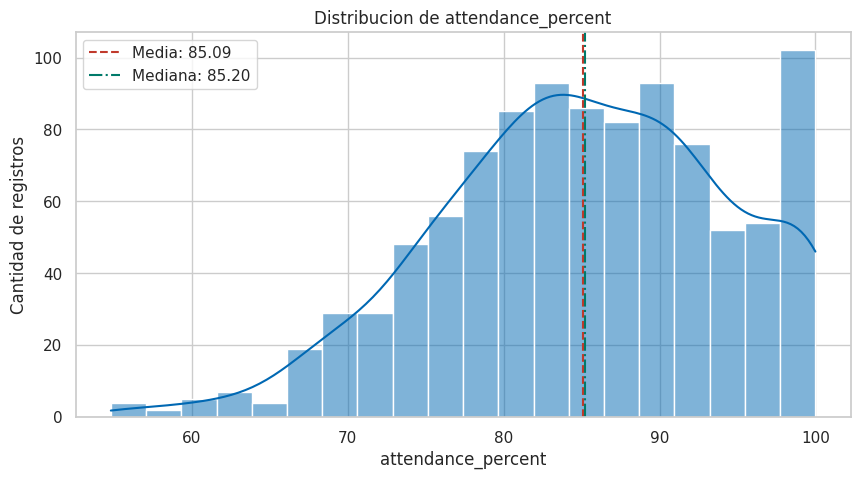

In [ ]:
media = df[columna_numerica].mean()
mediana = df[columna_numerica].median()
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x=columna_numerica,
    bins=20,
    kde=True,
    color="#0068B3"
)
plt.axvline(
    media,
    color="#C0392B",
    linestyle="--",
    label=f"Media: {media:.2f}"
)
plt.axvline(
    mediana,
    color="#007A6A",
    linestyle="-.",
    label=f"Mediana: {mediana:.2f}"
)
plt.title(f"Distribucion de {columna_numerica}")
plt.xlabel(columna_numerica)
plt.ylabel("Cantidad de registros")
plt.legend()
plt.show()

Los valores se concentran entre 3 y 4 horas, la forma tiende a estar mas alta en los primeros valores y una vez que pasa el promedio baja, si media y mediana estan cercanas, existe pequeños valores muy poco alejados, creo que si podria depender de

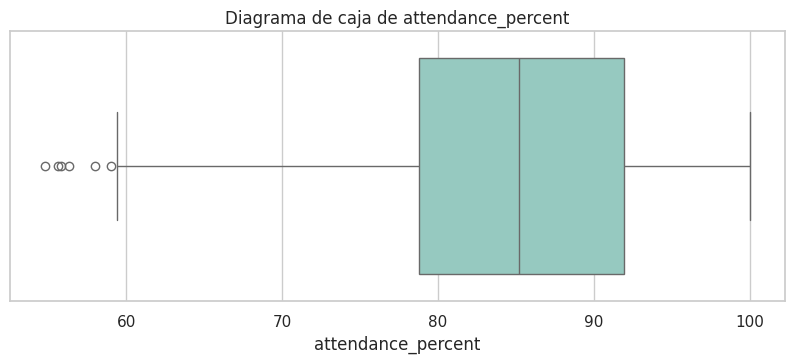

In [ ]:
plt.figure(figsize=(10, 3.5))
sns.boxplot(
x=df[columna_numerica],
color="#8ED1C6"
)
plt.title(f"Diagrama de caja de {columna_numerica}")
plt.xlabel(columna_numerica)
plt.show()

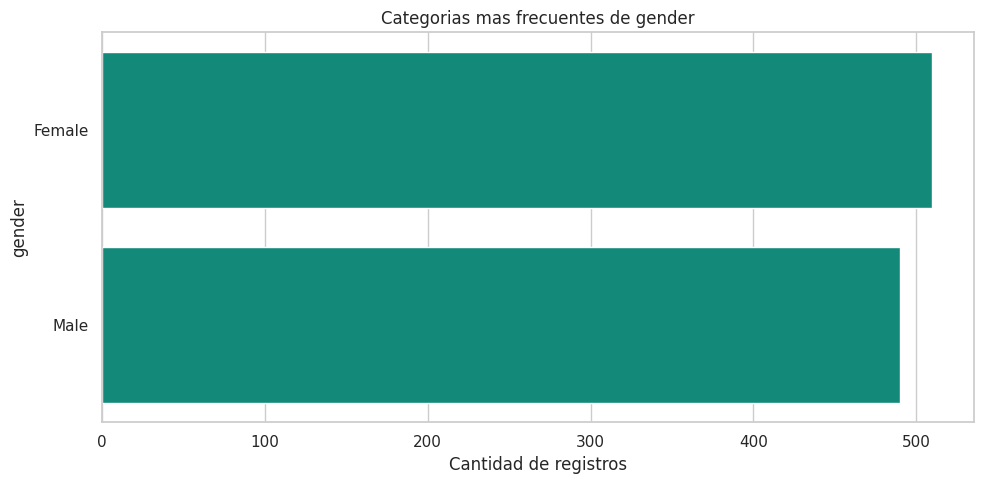

In [ ]:
top_categorias = df[columna_categorica].value_counts(
dropna=False
).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(
x=top_categorias.values,
y=top_categorias.index.astype(str),
color="#009C88"
)
plt.title(f"Categorias mas frecuentes de {columna_categorica}")
plt.xlabel("Cantidad de registros")
plt.ylabel(columna_categorica)
plt.tight_layout()
plt.show()


Domina la categoria genero female, los grupos estan equilibrados

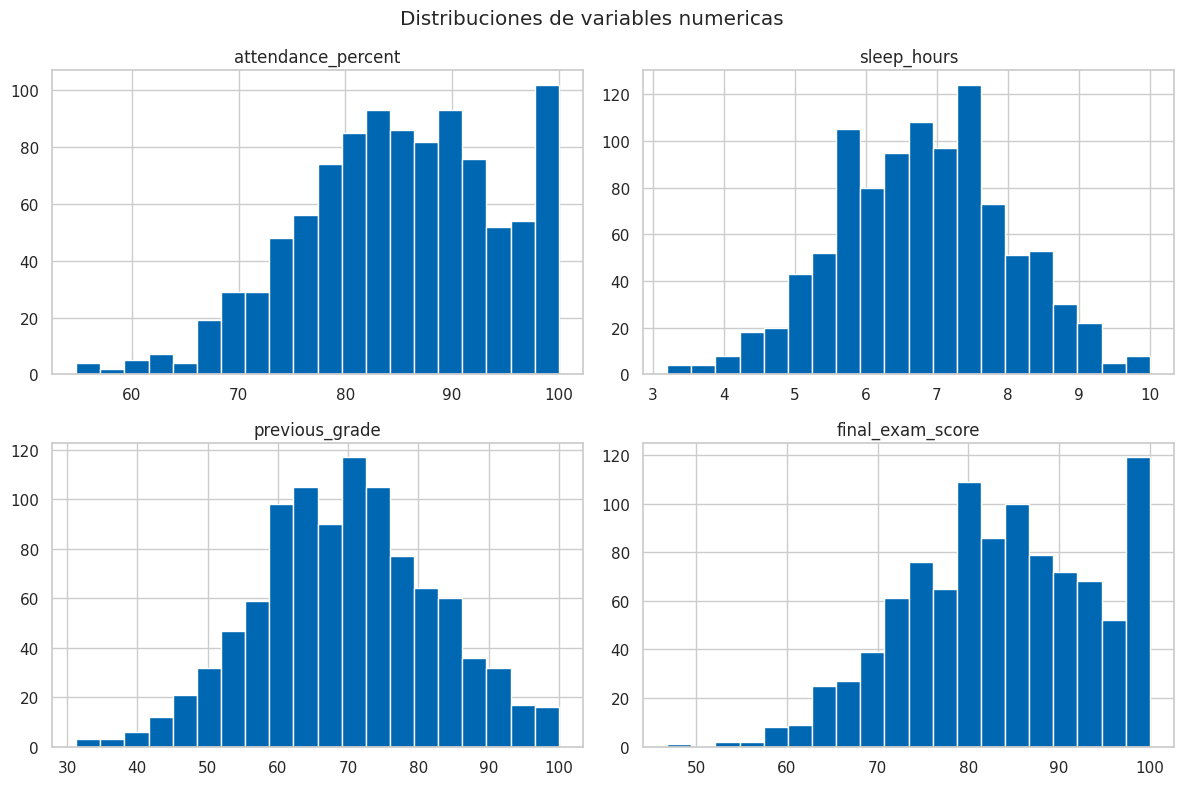

In [ ]:
seleccion_numericas = columnas_numericas[1:6]
if seleccion_numericas:
  df[seleccion_numericas].hist(
    bins=20,
    figsize=(12, 8),
    color="#0068B3",
    edgecolor="white"
  )
  plt.suptitle("Distribuciones de variables numericas")
  plt.tight_layout()
  plt.show()

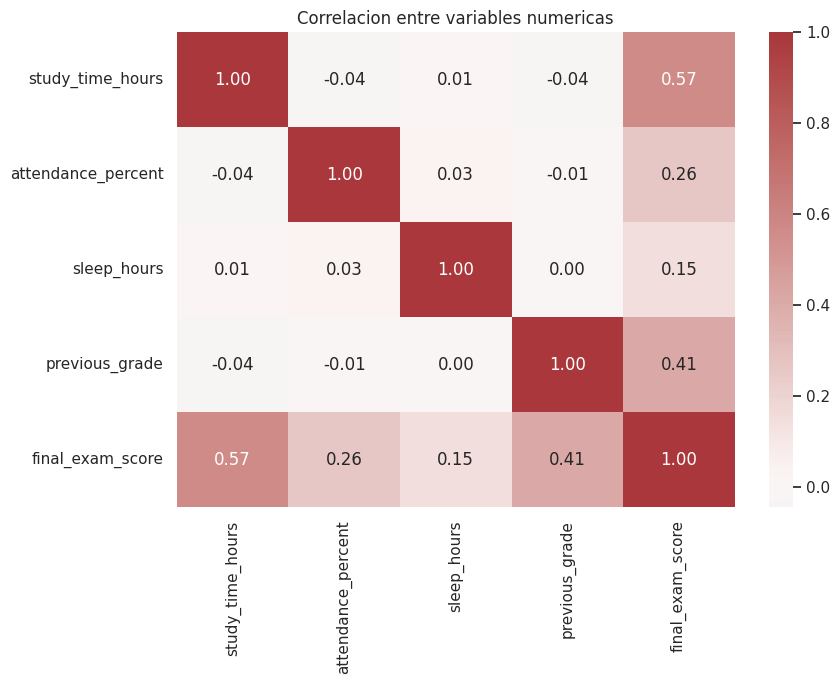

In [ ]:
seleccion_correlacion = columnas_numericas[:8]
if len(seleccion_correlacion) >= 2:
  matriz_correlacion = df[seleccion_correlacion].corr()
  plt.figure(figsize=(9, 7))
  sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0
  )
  plt.title("Correlacion entre variables numericas")
  plt.tight_layout()
  plt.show()

Hallazgos Principales:

Horas de estudio y nota final: Mientras más horas estudian, mejor les va en el examen; es la relación más clara con un 0,57.

Notas anteriores y nota final: A los que les iba bien antes les sigue yendo bien ahora, mostrando una conexión moderada de 0,41.

Asistencia y nota final: Ir a clases ayuda un poco (0,26), pero estar presente no te asegura por sí solo sacarte una buena nota.

Horas de sueño y nota final: Dormir más casi no se nota en la nota linealmente (0,15), probablemente porque pasarse de sueño o dormir muy poco afecta de otra forma.

Relación entre los hábitos de los alumnos: Los hábitos no dependen entre sí (valores cercanos a 0,00); por ejemplo, los que tienen buenas notas no necesariamente estudian más horas.

Dormir versus estudiar: Estudiar más horas no significa que los estudiantes estén durmiendo menos, ya que su relación es prácticamente cero (0,01).

## Preparación de los Datos

Dejamos los datos listos para que los algoritmos puedan procesarlos:

- Datos faltantes Decidir si rellenar o borrar los 102 vacíos en el nivel educativo de los padres (parental_education).
- Convertir texto a numerico: Transformar variables como género, acceso a internet o trabajo part-time a formato numérico (One-Hot o Label Encoding).
- Escalar números: Ajustar variables como horas de estudio o asistencia para que compartan la misma escala y ninguna opaque a otra.
- Seleccionar variables clave: Priorizar las horas de estudio y la nota previa por su alta correlación con el puntaje final, manteniendo las demás.
- Limpieza: Quitar el ID del estudiante (student_id), ya que no aporta información predictiva.

## Modelado

Dividimos los datos en entrenamiento y prueba (80/20) y probamos dos enfoques:

- Predecir nota exacta (Regresión): Probar Regresión Lineal, Random Forest o Gradient Boosting para estimar el puntaje final (final_exam_score).
- Predecir categoría/aprobación (Clasificación): Probar Regresión Logística, Random Forest o KNN para clasificar la calificación (final_grade).

## Evaluación

Medimos qué tan bien funcionan los modelos frente a los objetivos iniciales:

- Regresión: Revisar el error promedio (MAE, RMSE) y cuánto explica el modelo (R²).
- Clasificación Evaluar aciertos globales (Accuracy, Matriz de Confusión) y equilibrio de aciertos (Precisión, Recall, F1-score).
- Importancia de variables Comprobar si las horas de estudio y la nota previa siguen siendo las más determinantes según el modelo entrenado.

## Despliegue

- Compartir resultados Presentar a los docentes qué factores impactan más en el rendimiento de los alumnos.
- Propuesta práctica Diseñar un reporte o panel visual que alerte a tiempo si un estudiante baja su asistencia u horas de estudio.